# Chapter 4, Example 4: Learning an Exponential-Family Graphical Model

We study a homogeneous four-spin Ising chain with two parameters:

$$
p_{h,J}(\boldsymbol{x})
=\exp\left(h\,\phi_1(\boldsymbol{x})+J\,\phi_2(\boldsymbol{x})-\Phi(h,J)\right),
$$

where

$$
\phi_1(\boldsymbol{x})=\sum_{i=1}^4 x_i,
\qquad
\phi_2(\boldsymbol{x})=\sum_{i=1}^3 x_i x_{i+1},
$$

and $\Phi(h,J)=\log Z(h,J)$. The gradient of the average log-likelihood is the difference between empirical and model moments:

$$
\nabla \ell(h,J)
=\widehat{\boldsymbol{\mu}}-\mathbb{E}_{h,J}[\boldsymbol{\phi}(\boldsymbol{x})].
$$

Thus maximum-likelihood learning repeatedly calls an inference routine that evaluates model moments.

In [1]:
from pathlib import Path
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from scipy.optimize import minimize

CWD = Path.cwd()
if CWD.name == "ch04":
    NOTEBOOK_DIR = CWD
elif (CWD / "notebooks" / "ch04").exists():
    NOTEBOOK_DIR = CWD / "notebooks" / "ch04"
else:
    NOTEBOOK_DIR = CWD
FIG_DIR = NOTEBOOK_DIR / "figs"
FIG_DIR.mkdir(parents=True, exist_ok=True)
RNG = np.random.default_rng(577)

plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "figure.titlesize": 19,
    "lines.linewidth": 2.2,
})

DARK_NODE = "#315a78"
FACTOR_NODE = "#6b4c7a"


def save_figure(fig, stem: str) -> None:
    """Save a Matplotlib figure as both vector PDF and high-resolution PNG."""
    pdf_path = FIG_DIR / f"{stem}.pdf"
    png_path = FIG_DIR / f"{stem}.png"
    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(png_path, dpi=240, bbox_inches="tight")
    print(f"Saved: {pdf_path}")
    print(f"Saved: {png_path}")


def annotate_heatmap(ax, image, matrix, fmt=".2f"):
    """Use white text on dark cells and black text on light cells."""
    norm = image.norm
    cmap = image.cmap
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            rgba = cmap(norm(matrix[i, j]))
            luminance = 0.2126 * rgba[0] + 0.7152 * rgba[1] + 0.0722 * rgba[2]
            color = "black" if luminance > 0.58 else "white"
            ax.text(j, i, format(matrix[i, j], fmt), ha="center", va="center",
                    color=color, fontsize=12, fontweight="bold")

In [2]:
STATES = np.array(list(product([-1,1], repeat=4)), dtype=int)
PHI = np.column_stack([
    STATES.sum(axis=1),
    (STATES[:,:-1]*STATES[:,1:]).sum(axis=1),
])
THETA_TRUE = np.array([0.28,0.72])


def model(theta):
    logits = PHI @ theta
    shift = logits.max()
    w = np.exp(logits-shift)
    p = w/w.sum()
    logZ = shift + np.log(w.sum())
    moments = p @ PHI
    centered = PHI - moments
    covariance = (centered.T * p) @ centered
    return p, logZ, moments, covariance

p_true, logZ_true, mu_true, cov_true = model(THETA_TRUE)
print("True parameters:", THETA_TRUE)
print("True moments:", mu_true)
assert np.all(np.linalg.eigvalsh(cov_true) > 0)

True parameters: [0.28 0.72]
True moments: [2.29961764 2.10535491]


## 1. Generate observations and form empirical moments

The sufficient statistics compress the sample into a two-dimensional empirical moment vector. For this minimal exponential family, the exact MLE matches these empirical moments whenever they lie in the interior of the moment set.

In [3]:
def sample_data(size, rng=RNG):
    indices = rng.choice(len(STATES), size=size, p=p_true)
    return STATES[indices], PHI[indices]

S = 800
samples, sample_features = sample_data(S)
mu_hat = sample_features.mean(axis=0)
print("Empirical moments:", mu_hat)
print("Moment error:", mu_hat-mu_true)

Empirical moments: [2.2825 2.15  ]
Moment error: [-0.01711764  0.04464509]


## 2. Exact maximum likelihood

For average log-likelihood

$$
\ell(\boldsymbol{\theta})
=\boldsymbol{\theta}^{T}\widehat{\boldsymbol{\mu}}-\Phi(\boldsymbol{\theta}),
$$

we minimize $-\ell$. The Hessian is the model covariance of the sufficient statistics, so the negative log-likelihood is convex.

In [4]:
def fit_mle(mu_empirical, start=np.zeros(2)):
    trace=[]
    def fun(theta):
        p, logZ, moments, covariance = model(theta)
        value = logZ - theta @ mu_empirical
        gradient = moments - mu_empirical
        trace.append((theta.copy(), value, np.linalg.norm(gradient)))
        return value, gradient
    result = minimize(fun, start, jac=True, method="BFGS", options={"gtol":1e-10,"maxiter":500})
    return result, trace

result, trace = fit_mle(mu_hat)
theta_hat = result.x
_, _, mu_model, _ = model(theta_hat)
print("Estimated parameters:", theta_hat)
print("Model moments at MLE:", mu_model)
print("Empirical moments:", mu_hat)
print("Moment-matching residual:", mu_model-mu_hat)
assert np.linalg.norm(mu_model-mu_hat) < 1e-6

Estimated parameters: [0.2682176  0.75775364]
Model moments at MLE: [2.28250001 2.15      ]
Empirical moments: [2.2825 2.15  ]
Moment-matching residual: [ 5.22260279e-09 -1.39478429e-09]


## 3. Likelihood geometry

The first panel displays the convex negative log-likelihood surface. The second panel shows that optimization drives model moments toward the empirical moments.

Saved: figs/ch04_04_likelihood_and_moment_matching.pdf
Saved: figs/ch04_04_likelihood_and_moment_matching.png


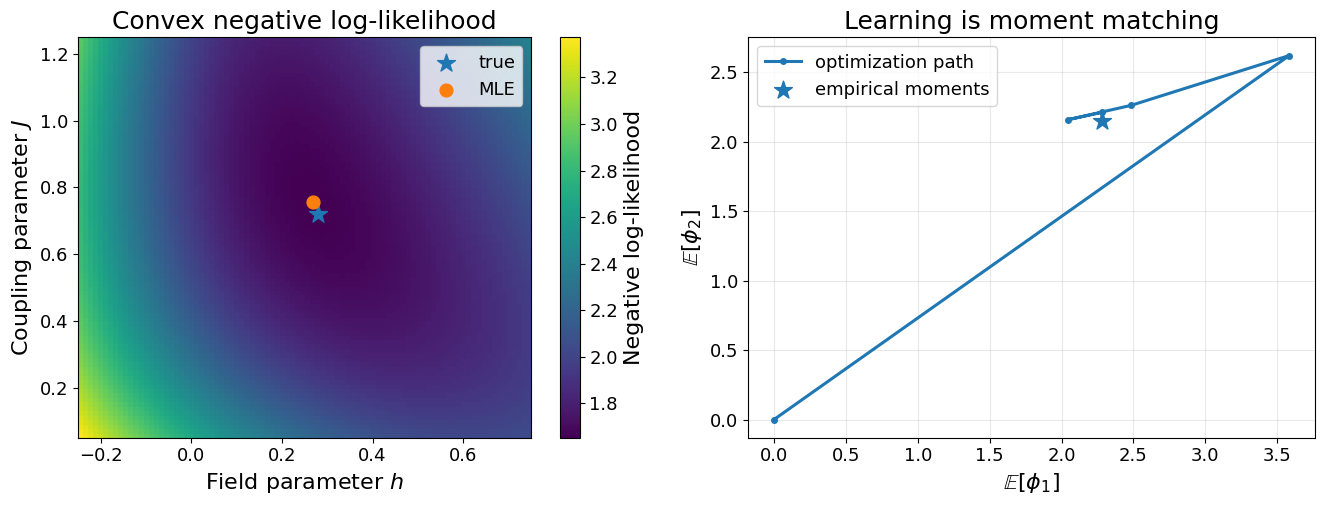

In [5]:
h_grid = np.linspace(-0.25,0.75,90)
J_grid = np.linspace(0.05,1.25,90)
NLL = np.zeros((len(J_grid),len(h_grid)))
for i,J in enumerate(J_grid):
    for j,h in enumerate(h_grid):
        _, logZ, _, _ = model(np.array([h,J]))
        NLL[i,j] = logZ - np.array([h,J]) @ mu_hat

fig, axes = plt.subplots(1,2,figsize=(13.5,5.3))
image=axes[0].imshow(NLL,origin="lower",aspect="auto",
                     extent=[h_grid[0],h_grid[-1],J_grid[0],J_grid[-1]])
axes[0].scatter([THETA_TRUE[0]],[THETA_TRUE[1]],marker="*",s=180,label="true")
axes[0].scatter([theta_hat[0]],[theta_hat[1]],marker="o",s=85,label="MLE")
axes[0].set_xlabel(r"Field parameter $h$")
axes[0].set_ylabel(r"Coupling parameter $J$")
axes[0].set_title("Convex negative log-likelihood")
axes[0].legend()
fig.colorbar(image,ax=axes[0],label="Negative log-likelihood")

trace_theta=np.array([t[0] for t in trace])
model_moments=np.array([model(theta)[2] for theta in trace_theta])
axes[1].plot(model_moments[:,0],model_moments[:,1],marker="o",markersize=4,label="optimization path")
axes[1].scatter([mu_hat[0]],[mu_hat[1]],marker="*",s=180,label="empirical moments")
axes[1].set_xlabel(r"$\mathbb{E}[\phi_1]$")
axes[1].set_ylabel(r"$\mathbb{E}[\phi_2]$")
axes[1].set_title("Learning is moment matching")
axes[1].legend()
axes[1].grid(alpha=0.28)
fig.tight_layout()
save_figure(fig,"ch04_04_likelihood_and_moment_matching")
plt.show()

## 4. Finite-sample parameter recovery

We repeat the experiment at several sample sizes. The estimates fluctuate because empirical moments fluctuate. The log-partition function makes each fit exact but cannot remove sampling uncertainty.

Saved: figs/ch04_04_parameter_recovery.pdf
Saved: figs/ch04_04_parameter_recovery.png


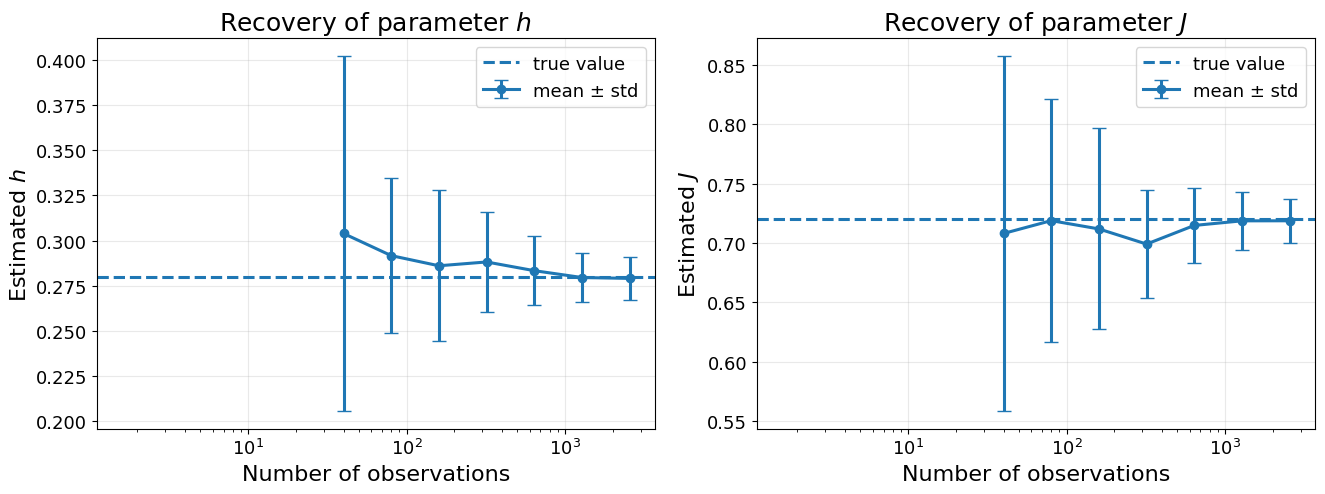

In [6]:
sizes = np.array([40,80,160,320,640,1280,2560])
repetitions=35
estimates=np.zeros((len(sizes),repetitions,2))
for i,size in enumerate(sizes):
    for r in range(repetitions):
        _, features=sample_data(int(size))
        result,_=fit_mle(features.mean(axis=0))
        estimates[i,r]=result.x

means=estimates.mean(axis=1)
stds=estimates.std(axis=1)
fig,axes=plt.subplots(1,2,figsize=(13.5,5.2),sharex=True)
for k,(name,true_value) in enumerate(zip([r"$h$",r"$J$"],THETA_TRUE)):
    axes[k].errorbar(sizes,means[:,k],yerr=stds[:,k],marker="o",capsize=5,label="mean ± std")
    axes[k].axhline(true_value,linestyle="--",label="true value")
    axes[k].set_xscale("log")
    axes[k].set_xlabel("Number of observations")
    axes[k].set_ylabel(f"Estimated {name}")
    axes[k].set_title(f"Recovery of parameter {name}")
    axes[k].grid(alpha=0.28)
    axes[k].legend()
fig.tight_layout()
save_figure(fig,"ch04_04_parameter_recovery")
plt.show()

## 5. What becomes difficult in large models

Here every evaluation of $\Phi(\boldsymbol{\theta})$ and its gradient uses exact enumeration over 16 states. In a large graphical model, the optimizer repeatedly requests a partition function and model moments. Learning is therefore coupled to inference. Later chapters replace exact inference by tree methods, variational approximations, MCMC, pseudo-likelihood, interaction screening, or learned surrogates.

## Exercises

1. Fit separate fields $h_i$ and couplings $J_i$. Check whether all empirical sufficient statistics are matched.
2. Add an $\ell_2$ penalty and derive the modified moment-matching equation.
3. Use a very small sample and identify cases where the unregularized MLE moves toward the boundary or becomes numerically unstable.
4. Replace the Ising family by a Gaussian graphical model and show that maximum likelihood matches empirical first and second moments.